In [1]:
from gcmc import gcmc_analysis
from gcmc.simulation_analysis import simulation_capacity
from gcmc.preprocess import downsample_manifolds, reallocate_origin, shuffle_manifolds

import pandas as pd
import numpy as np
import time
from pathlib import Path
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

## load data

In [4]:
base_path = Path('../')
data_path = base_path / 'data' / 'Zak_2024'
index_filepath = data_path / 'odor_index.mat'
import h5py
with h5py.File(index_filepath, 'r') as f:
    odor_index = f['odor_index']
    odor_list = []
    for i in range(odor_index.shape[1]):
        ref = odor_index[0, i]
        arr = np.array(f[ref]).squeeze()   # .squeeze() removes single-dimensional entries
        odor_list.append(arr)


one_hot_indices = np.zeros((len(odor_list), 16))
for mix_idx, odors in enumerate(odor_list):
    one_hot_indices[mix_idx, odors.astype(int) - 1] = 1

# load OSN and bouton data
mouse_idx = 3 # pick a mouse (1, 2, 3)
osn_df = pd.read_csv(data_path / f'mouse{mouse_idx}_osn.csv').T 
osn_df # (100 mixtures, N OSNs)
bouton1_df = pd.read_csv(data_path / f'mouse{mouse_idx}_bouton1.csv').T # (100 mixtures, N boutons)
if mouse_idx != 3:
    bouton2_df = pd.read_csv(data_path / f'mouse{mouse_idx}_bouton2.csv').T # (100 mixtures, N boutons)

for odor1 in range(16):
    for odor2 in range(16):
        print(f'odors: {odor1}, {odor2}')
        print(np.sum((one_hot_indices[:, odor1] == 1) & (one_hot_indices[:, odor2] == 0)), np.sum((one_hot_indices[:, odor1] == 0) & (one_hot_indices[:, odor2] == 1)))
for odor in range(16):
    print(np.sum((one_hot_indices[:, odor] == 1)))

print(one_hot_indices.shape)

odors: 0, 0
0 0
odors: 0, 1
20 16
odors: 0, 2
18 22
odors: 0, 3
14 18
odors: 0, 4
18 13
odors: 0, 5
15 18
odors: 0, 6
21 15
odors: 0, 7
19 16
odors: 0, 8
17 19
odors: 0, 9
18 19
odors: 0, 10
16 21
odors: 0, 11
14 21
odors: 0, 12
22 15
odors: 0, 13
17 18
odors: 0, 14
15 18
odors: 0, 15
19 14
odors: 1, 0
16 20
odors: 1, 1
0 0
odors: 1, 2
10 18
odors: 1, 3
15 23
odors: 1, 4
19 18
odors: 1, 5
14 21
odors: 1, 6
17 15
odors: 1, 7
15 16
odors: 1, 8
16 22
odors: 1, 9
18 23
odors: 1, 10
14 23
odors: 1, 11
13 24
odors: 1, 12
21 18
odors: 1, 13
16 21
odors: 1, 14
14 21
odors: 1, 15
17 16
odors: 2, 0
22 18
odors: 2, 1
18 10
odors: 2, 2
0 0
odors: 2, 3
17 17
odors: 2, 4
23 14
odors: 2, 5
19 18
odors: 2, 6
21 11
odors: 2, 7
21 14
odors: 2, 8
17 15
odors: 2, 9
20 17
odors: 2, 10
17 18
odors: 2, 11
17 20
odors: 2, 12
21 10
odors: 2, 13
22 19
odors: 2, 14
17 16
odors: 2, 15
23 14
odors: 3, 0
18 14
odors: 3, 1
23 15
odors: 3, 2
17 17
odors: 3, 3
0 0
odors: 3, 4
25 16
odors: 3, 5
21 20
odors: 3, 6
23 13


## GLUE analysis of OSN and bouton imaging data

In [48]:
from joblib import Parallel, delayed
import numpy as np
import time

def _process_odor(odor, responses, labels_matrix, scale):
    # responses: (neurons, datapoints)
    # labels_matrix: (datapoints, odors)
    labels = labels_matrix[:, odor]
    dichotomies = [np.array([1, -1])]

    # split and recenter
    manifolds = [
        responses[:, labels.astype(bool)],
        responses[:, ~labels.astype(bool)]
    ]
    m_min = int(min(manifold.shape[1] for manifold in manifolds))
    manifolds = downsample_manifolds(manifolds, n_points=m_min, seed=42)
    manifolds_reallocated = reallocate_origin(manifolds, scale=scale)

    # true capacity
    ret = gcmc_analysis(manifolds_reallocated, dichotomies)

    # shuffled capacity
    manifolds_shuffled = shuffle_manifolds(manifolds, seed=42)
    manifolds_reallocated = reallocate_origin(manifolds_shuffled, scale=scale)
    shuffle_ret = gcmc_analysis(manifolds_reallocated, dichotomies)

    print(f"[odor={odor}]→ cap={ret['capacity']:.2f} "
          f"shuffle cap={shuffle_ret['capacity']:.2f}")

    return [
        odor,
        ret['capacity'],
        shuffle_ret['capacity'],
        ret['dimension'],
        ret['radius'],
        ret['utility'],
        ret['center_alignment'],
        ret['axis_alignment'],
        ret['center_axis_alignment'],
    ]

def run_gcmc_parallel(df, one_hot_indices, scale=0.0, n_jobs=-1):
    # Precompute everything shared
    responses = df.to_numpy().T
    labels_matrix = one_hot_indices

    # dispatch one task per odor
    results = Parallel(
        n_jobs=n_jobs,      # -1 means “use all CPUs”
        verbose=5           # progress reporting
    )(
        delayed(_process_odor)(odor, responses, labels_matrix, scale)
        for odor in range(labels_matrix.shape[1])
    )
    return results

# usage
scale = 0.0
osn_result    = run_gcmc_parallel(osn_df,    one_hot_indices, scale)
bouton1_result  = run_gcmc_parallel(bouton1_df, one_hot_indices, scale)
if mouse_idx != 3:
    bouton2_result  = run_gcmc_parallel(bouton2_df, one_hot_indices, scale)

# then turn into DataFrames and save exactly as before...
scale = 0.0 # reallocate origin to centroid of manifolds
osn_result_df = pd.DataFrame(osn_result, columns=['odor', 'capacity', 'shuffle_capacity', 'dimension', 'radius', 'utility', 'center_alignment', 'axis_alignment', 'center_axis_alignment'])
bouton1_result_df = pd.DataFrame(bouton1_result, columns=['odor', 'capacity', 'shuffle_capacity', 'dimension', 'radius', 'utility', 'center_alignment', 'axis_alignment', 'center_axis_alignment'])
if mouse_idx != 3:
    bouton2_result_df = pd.DataFrame(bouton2_result, columns=['odor', 'capacity', 'shuffle_capacity', 'dimension', 'radius', 'utility', 'center_alignment', 'axis_alignment', 'center_axis_alignment'])
osn_result_df.to_csv(data_path / f'mouse{mouse_idx}_osn_gcmc_scale{scale}_results.csv')
bouton1_result_df.to_csv(data_path / f'mouse{mouse_idx}_bouton1_gcmc_scale{scale}_results.csv')
bouton2_result_df.to_csv(data_path / f'mouse{mouse_idx}_bouton2_gcmc_scale{scale}_results.csv')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.


[odor=6]→ cap=0.09 shuffle cap=0.08
[odor=4]→ cap=0.08 shuffle cap=0.07
[odor=1]→ cap=0.08 shuffle cap=0.07
[odor=12]→ cap=0.23 shuffle cap=0.08
[odor=0]→ cap=0.09 shuffle cap=0.06
[odor=7]→ cap=0.06 shuffle cap=0.07


[Parallel(n_jobs=-1)]: Done   5 out of  16 | elapsed:    0.9s remaining:    2.0s
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    1.0s remaining:    0.8s


[odor=13]→ cap=0.06 shuffle cap=0.06
[odor=8]→ cap=0.06 shuffle cap=0.05
[odor=2]→ cap=0.06 shuffle cap=0.06
[odor=9]→ cap=0.07 shuffle cap=0.06
[odor=5]→ cap=0.07 shuffle cap=0.06
[odor=3]→ cap=0.16 shuffle cap=0.05
[odor=10]→ cap=0.18 shuffle cap=0.05
[odor=11]→ cap=0.05 shuffle cap=0.05


[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:    1.2s remaining:    0.3s


...

[Parallel(n_jobs=-1)]: Done   5 out of  16 | elapsed:    0.8s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    1.0s remaining:    0.7s


[odor=13]→ cap=0.06 shuffle cap=0.06
[odor=9]→ cap=0.07 shuffle cap=0.06
[odor=8]→ cap=0.06 shuffle cap=0.06
[odor=3]→ cap=0.07 shuffle cap=0.05
[odor=5]→ cap=0.06 shuffle cap=0.05
[odor=10]→ cap=0.09 shuffle cap=0.05
[odor=11]→ cap=0.05 shuffle cap=0.05


[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:    1.1s remaining:    0.3s


[odor=15]→ cap=0.08 shuffle cap=0.07
[odor=14]→ cap=0.06 shuffle cap=0.06


[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:    1.5s finished


Text(0.5, 1.0, 'One vs rest capacity across odors and regions')

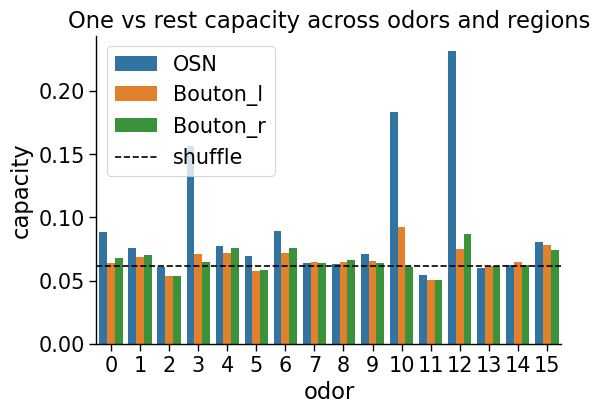

In [49]:
osn_result_df['region'] = 'OSN'
bouton1_result_df['region'] = 'Bouton_l'
bouton2_result_df['region'] = 'Bouton_r'
cap_result_df = pd.concat([osn_result_df, bouton1_result_df, bouton2_result_df], axis=0)

sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"
plt.figure(figsize=(6,4))
sns.despine()
sns.barplot(cap_result_df, x='odor', y='capacity', hue='region')
plt.axhline(cap_result_df['shuffle_capacity'].mean(), linestyle='--', color='k', label='shuffle')
plt.legend()
sns.despine()
plt.title('One vs rest capacity across odors and regions')


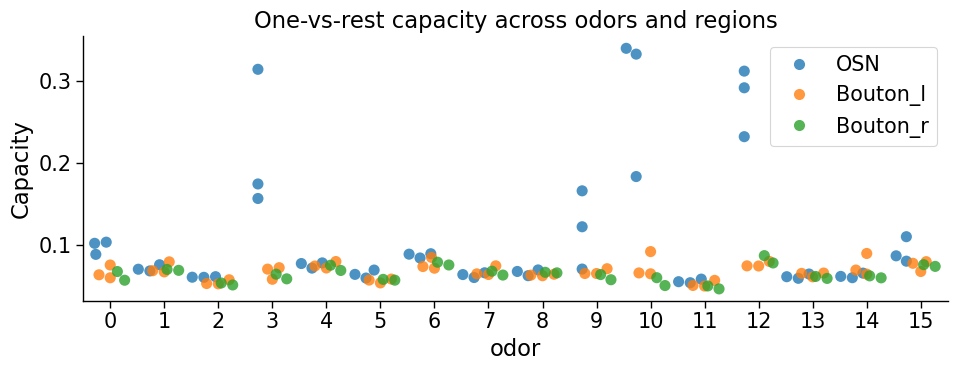

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Load & concatenate all mice, then drop bouton2 for mouse3 ---
dfs = []
for mouse_idx in (1,2,3):
    for region, stem in [('OSN','osn'),
                         ('Bouton_l','bouton1'),
                         ('Bouton_r','bouton2')]:
        fn = data_path / f'mouse{mouse_idx}_{stem}_gcmc_scale{scale}_results.csv'
        df = pd.read_csv(fn)
        df['mouse']  = mouse_idx
        df['region'] = region
        dfs.append(df)

cap_all = pd.concat(dfs, ignore_index=True)

# Omit bouton2 (region="Bouton_r") for mouse 3
cap_all = cap_all[~((cap_all.mouse == 3) & (cap_all.region == 'Bouton_r'))]

sns.set_context("paper", font_scale=1.7)
plt.figure(figsize=(10,4))

# 1) beeswarm of every point
sns.swarmplot(data=cap_all,
              x='odor', y='capacity', hue='region',
              dodge=True,  # separate regions side by side
              size=8,      # dot size
              alpha=0.8)

# # 2) overlay mean as a big “X”
# means = (cap_all
#          .groupby(['odor','region'])['capacity']
#          .mean()
#          .reset_index())
# for i, (odor, region, m) in enumerate(means.itertuples(index=False)):
#     # compute x‐position of each region‐dodge
#     odor_levels  = means['odor'].unique()
#     region_levels = means['region'].unique()
#     j = list(odor_levels).index(odor)
#     k = list(region_levels).index(region)
#     width = 0.8 / len(region_levels)
#     x = j - 0.4 + (k+0.5)*width
#     plt.scatter(x, m, marker='X', s=200, color='k', edgecolor='white')

plt.ylabel('Capacity')
plt.title('One‐vs‐rest capacity across odors and regions')
sns.despine()
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(base_path / 'figures' / 'manuscript' / f'all_mice_capacity_Zak2024.svg', dpi=600, bbox_inches='tight')
plt.savefig(base_path / 'figures' / 'manuscript' / f'all_mice_capacity_Zak2024.png', dpi=600, bbox_inches='tight')

In [14]:
## not parallelized

# def run_gcmc(df, one_hot_indices, scale=0.0):
#     '''
#     df: (n_mixtures, neurons)
#     one_hot_indices: (datapoints, odors)
#     '''
#     results_local = []
#     for odor in range(one_hot_indices.shape[1]):
#         labels = one_hot_indices[:, odor]
#         responses = df.to_numpy().T # (neurons, datapoints)
#         dichotomies = [np.array([1, -1])]

#         manifolds = [responses[:, labels.astype(bool)], responses[:, ~labels.astype(bool)]]
#         manifolds_reallocated = reallocate_origin(manifolds, scale=scale)

        
#         start = time.time()
#         ret = gcmc_analysis(manifolds_reallocated, dichotomies)
#         # simcap = simulation_capacity(manifolds, dichotomies)
#         elapsed = time.time() - start

#         # check shuffled manifolds
#         seed = 42
#         manifolds_shuffled = shuffle_manifolds(manifolds, seed=seed)
#         start = time.time()
#         manifolds_reallocated = reallocate_origin(manifolds_shuffled, scale=scale)
#         shuffle_ret = gcmc_analysis(manifolds_shuffled, dichotomies)
#         # simcap = simulation_capacity(manifolds_shuffled, dichotomies)
#         elapsed = time.time() - start



#         # optional: print shapes & timing
#         print(f"[odor={odor}]"
#               f"→ cap={ret['capacity']:.2f}, shuffle cap={shuffle_ret['capacity']:.2f} in {elapsed:.1f}s")
#             # f"→ cap={ret['capacity']:.2f}, sim_cap={simcap:.2f} in {elapsed:.1f}s")

#         results_local.append([
#             odor,
#             ret['capacity'],
#             shuffle_ret['capacity'],
#             # simcap,
#             ret['dimension'],
#             ret['radius'],
#             ret['utility'],
#             ret['center_alignment'],
#             ret['axis_alignment'],
#             ret['center_axis_alignment'],
#         ])
#     return results_local

# scale = 0.0 # reallocate origin to centroid of manifolds
# osn_result = run_gcmc(osn_df, one_hot_indices, scale)
# bouton1_result = run_gcmc(bouton1_df, one_hot_indices, scale)
# bouton2_result = run_gcmc(bouton2_df, one_hot_indices, scale)
# osn_result_df = pd.DataFrame(osn_result, columns=['odor', 'capacity', 'shuffle_capacity', 'dimension', 'radius', 'utility', 'center_alignment', 'axis_alignment', 'center_axis_alignment'])
# bouton1_df = pd.DataFrame(bouton1_result, columns=['odor', 'capacity', 'shuffle_capacity', 'dimension', 'radius', 'utility', 'center_alignment', 'axis_alignment', 'center_axis_alignment'])
# bouton2_df = pd.DataFrame(bouton2_result, columns=['odor', 'capacity', 'shuffle_capacity', 'dimension', 'radius', 'utility', 'center_alignment', 'axis_alignment', 'center_axis_alignment'])
# osn_result_df.to_csv(data_path / f'mouse{mouse_idx}_osn_gcmc_results.csv')
# bouton1_df.to_csv(data_path / f'mouse{mouse_idx}_bouton1_gcmc_scale{scale}_results.csv')
# bouton2_df.to_csv(data_path / f'mouse{mouse_idx}_bouton2_gcmc_scale{scale}_results.csv')

## logistic regression

X.shape: (100, 120)


X.shape: (100, 106)


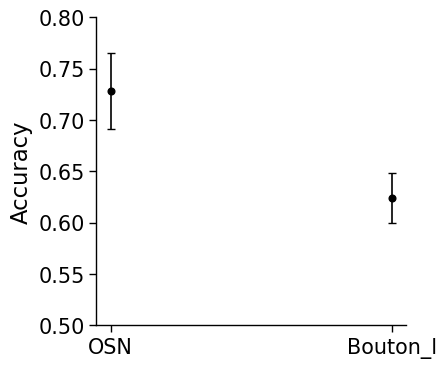

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

def ridge_logistic_cv(df: pd.DataFrame,
                      one_hot_indices: np.ndarray,
                      C: float = 1.0,
                      n_splits: int = 5,
                      random_state: int = 42) -> pd.DataFrame:
    """
    Runs n_splits‐fold stratified CV of an L2‐penalized logistic regression
    for each odor (binary: odor vs. all others).
    
    Returns a DataFrame with per‐odor mean & std accuracy.
    """
    if df.shape[1] > 120:
        df = df.sample(n=120, axis=1, random_state=random_state, replace=False) # limit to 120 neurons for fair comparison

    X = df.values                          # shape (n_samples, n_features)
    print(f'X.shape: {X.shape}')
    n_odors = one_hot_indices.shape[1]
    results = []
    
    # ensure we have at least two classes present for each odor
    for odor in range(n_odors):
        y = one_hot_indices[:, odor]
        # skip if odor never present or always present
        if y.sum() == 0 or y.sum() == len(y):
            print(f"Skipping odor {odor}: only one class present.")
            continue
        
        skf = StratifiedKFold(n_splits=n_splits,
                              shuffle=True,
                              random_state=random_state)
        clf = LogisticRegression(penalty='l2',
                                 C=C,
                                 solver='liblinear',
                                 random_state=random_state)
        
        scores = cross_val_score(clf,
                                 X,
                                 y,
                                 cv=skf,
                                 scoring='accuracy',
                                 n_jobs=-1)
        
        results.append({
            'odor': odor,
            'mean_accuracy': scores.mean(),
            'std_accuracy': scores.std(),
            'all_scores': scores
        })
        # print(f'Odor={odor}, mean_acc={scores.mean():.4f}, std_acc={scores.std():.4f}, go_size={int(np.sum(y))}/{len(y)}')
    
    return pd.DataFrame(results)


# regress with CV
results_osn = ridge_logistic_cv(osn_df, one_hot_indices, C=1.0, n_splits=5)
results_bouton1 = ridge_logistic_cv(bouton1_df, one_hot_indices)
if mouse_idx != 3:
    results_bouton2 = ridge_logistic_cv(bouton2_df, one_hot_indices)

# plot
sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"
plt.figure(figsize=(4,4))
if mouse_idx != 3:
    mean_results = [results_osn['mean_accuracy'].mean(), results_bouton1['mean_accuracy'].mean(), results_bouton2['mean_accuracy'].mean()]
    stderr_results = [results_osn['mean_accuracy'].std() / np.sqrt(len(results_osn)), results_bouton1['mean_accuracy'].std() / np.sqrt(len(results_osn)), results_bouton2['mean_accuracy'].std() / np.sqrt(len(results_osn))]
    plt.errorbar(['OSN', 'Bouton_l', 'Bouton_r'], mean_results, yerr=stderr_results, capsize=3, fmt='o', color='black')
else:
    mean_results = [results_osn['mean_accuracy'].mean(), results_bouton1['mean_accuracy'].mean()]
    stderr_results = [results_osn['mean_accuracy'].std() / np.sqrt(len(results_osn)), results_bouton1['mean_accuracy'].std() / np.sqrt(len(results_osn))]
    plt.errorbar(['OSN', 'Bouton_l'], mean_results, yerr=stderr_results, capsize=3, fmt='o', color='black')
plt.ylabel('Accuracy')
plt.ylim(0.5, 0.8)
sns.despine()
plt.savefig(base_path / 'figures' / 'manuscript' / f'mouse{mouse_idx}_decodability_Zak2024.png', dpi=600)
plt.savefig(base_path / 'figures' / 'manuscript' / f'mouse{mouse_idx}_decodability_Zak2024.svg', dpi=600)

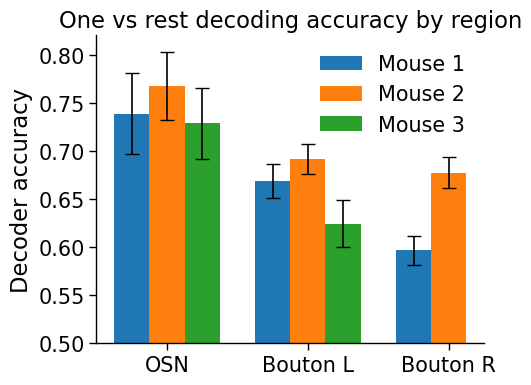

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- your existing setup ---
base_path = Path('../')
data_path = base_path / 'data' / 'Zak_2024'
index_filepath = data_path / 'odor_index.mat'
import h5py
with h5py.File(index_filepath, 'r') as f:
    odor_index = f['odor_index']
    odor_list = []
    for i in range(odor_index.shape[1]):
        ref = odor_index[0, i]
        arr = np.array(f[ref]).squeeze()
        odor_list.append(arr)

one_hot_indices = np.zeros((len(odor_list), 16))
for mix_idx, odors in enumerate(odor_list):
    one_hot_indices[mix_idx, odors.astype(int) - 1] = 1

def ridge_logistic_cv(df: pd.DataFrame,
                      one_hot_indices: np.ndarray,
                      C: float = 1.0,
                      n_splits: int = 5,
                      random_state: int = 42) -> pd.DataFrame:
    if df.shape[1] > 120:
        df = df.sample(n=120, axis=1, random_state=random_state, replace=False)
    X = df.values
    results = []
    for odor in range(one_hot_indices.shape[1]):
        y = one_hot_indices[:, odor]
        if y.sum() == 0 or y.sum() == len(y):
            continue
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        clf = LogisticRegression(penalty='l2', C=C, solver='liblinear', random_state=random_state)
        scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
        results.append({
            'odor': odor,
            'mean_accuracy': scores.mean(),
            'std_accuracy': scores.std(),
            'all_scores': scores
        })
    return pd.DataFrame(results)


# --- loop over mice and collect stats ---
mice = [1, 2, 3]
regions = ['OSN', 'Bouton1', 'Bouton2']
# we'll build a dict: stats[mouse][region] = (mean, sem)
stats = {m: {} for m in mice}

for m in mice:
    # load data
    osn_df     = pd.read_csv(data_path / f'mouse{m}_osn.csv').T
    bouton1_df = pd.read_csv(data_path / f'mouse{m}_bouton1.csv').T
    results_osn     = ridge_logistic_cv(osn_df,     one_hot_indices)
    results_bouton1 = ridge_logistic_cv(bouton1_df, one_hot_indices)
    # compute mean & SEM
    stats[m]['OSN']      = (results_osn['mean_accuracy'].mean(),
                            results_osn['mean_accuracy'].std()/np.sqrt(len(results_osn)))
    stats[m]['Bouton1']  = (results_bouton1['mean_accuracy'].mean(),
                            results_bouton1['mean_accuracy'].std()/np.sqrt(len(results_bouton1)))
    # bouton2 only exists for mice 1 & 2
    if m != 3:
        bouton2_df = pd.read_csv(data_path / f'mouse{m}_bouton2.csv').T
        results_bouton2 = ridge_logistic_cv(bouton2_df, one_hot_indices)
        stats[m]['Bouton2'] = (results_bouton2['mean_accuracy'].mean(),
                                results_bouton2['mean_accuracy'].std()/np.sqrt(len(results_bouton2)))
    else:
        stats[m]['Bouton2'] = (np.nan, np.nan)


# --- plotting ---
sns.set_context("paper", font_scale=1.7)
fig, ax = plt.subplots(figsize=(5,4))

x = np.arange(len(regions))
width = 0.25

for idx, m in enumerate(mice):
    means  = [stats[m][r][0] for r in regions]
    sems   = [stats[m][r][1] for r in regions]
    # shift each mouse left/center/right
    shift = (idx - 1) * width
    bars = ax.bar(x + shift, means, width, label=f'Mouse {m}')
    ax.errorbar(x + shift, means, yerr=sems, fmt='none', capsize=5, color='black')

ax.set_xticks(x)
regions = ['OSN', 'Bouton L', 'Bouton R']
ax.set_xticklabels(regions)
ax.set_ylabel('Decoder accuracy')
ax.set_ylim(0.5, 0.82)
ax.legend(frameon=False)
sns.despine()
# plt.tight_layout()
plt.title('One vs rest decoding accuracy by region')

# save
fig.savefig(base_path / 'figures' / 'manuscript' / f'all_mice_decodability_Zak2024.png', dpi=600, bbox_inches='tight')
fig.savefig(base_path / 'figures' / 'manuscript' / f'all_mice_decodability_Zak2024.svg', dpi=600, bbox_inches='tight')

(array([40.,  0., 20.,  0.,  0.,  0., 20.,  0.,  0., 20.]),
 array([ 1. ,  2.1,  3.2,  4.3,  5.4,  6.5,  7.6,  8.7,  9.8, 10.9, 12. ]),
 <BarContainer object of 10 artists>)

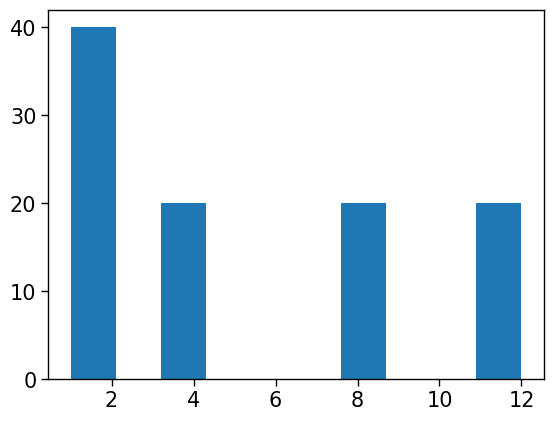

In [10]:
plt.hist(one_hot_indices.sum(1))

## sparsity analysis of mixtures

In [9]:
# odor mixture identities
base_path = Path('/Users/georgecai/Library/CloudStorage/OneDrive-HarvardUniversity/Documents/Murthy_lab/odor_mix_code')
data_path = base_path / 'data' / 'Zak_2024'
index_filepath = data_path / 'odor_index.mat'
import h5py
with h5py.File(index_filepath, 'r') as f:
    odor_index = f['odor_index']
    odor_list = []
    for i in range(odor_index.shape[1]):
        ref = odor_index[0, i]
        arr = np.array(f[ref]).squeeze()
        odor_list.append(arr)

one_hot_indices = np.zeros((len(odor_list), 16))
for mix_idx, odors in enumerate(odor_list):
    one_hot_indices[mix_idx, odors.astype(int) - 1] = 1

In [35]:
def population_sparsity(resp):
    '''
    resp: np.array with (glomeruli, stimuli)

    return
    np.array with (stimuli)
    '''
    N = len(resp)
    prefactor = 1# / (1 - 1/N)
    numerator = np.mean(resp, axis=0) ** 2
    denominator = np.mean(resp ** 2, axis=0) 
    return prefactor * (1 - numerator / denominator)


bg_complexities = one_hot_indices.sum(axis=1)

# --- loop over mice and collect stats ---
mice = [1, 2, 3]
regions = ['OSN', 'Bouton1', 'Bouton2']
# we'll build a dict: stats[mouse][region] = (mean, sem)
stats = {m: {} for m in mice}

results = {}

for m in mice:
    # load data
    results[m] = {}
    osn_df     = pd.read_csv(data_path / f'mouse{m}_osn.csv').T
    for bg_complexity in np.unique(bg_complexities):
        mask = bg_complexities == bg_complexity
        responses = osn_df.to_numpy()[mask].T # (neurons, stimuli)
        sparsities = population_sparsity(responses)

        results[m][bg_complexity] = [np.mean(sparsities), np.std(sparsities) / np.sqrt(len(sparsities))]


df.shape: (100, 133)
(133, 16)
(133, 24)
(133, 20)
(133, 20)
(133, 20)
df.shape: (100, 178)
(178, 16)
(178, 24)
(178, 20)
(178, 20)
(178, 20)
df.shape: (100, 137)
(137, 16)
(137, 24)
(137, 20)
(137, 20)
(137, 20)


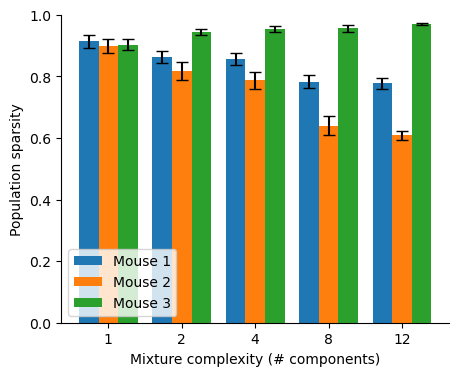

In [89]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

def population_sparsity(resp):
    '''
    resp: np.array with shape (neurons, stimuli)
    return: np.array with shape (stimuli,)
    '''
    N = len(resp)
    prefactor = 1  # / (1 - 1/N) if you want the Treves-Rolls correction
    with np.errstate(divide='ignore', invalid='ignore'):
        numerator = np.mean(resp, axis=0) ** 2
        denominator = np.mean(resp ** 2, axis=0)
        spars = prefactor * (1 - numerator / denominator)
    return np.nan_to_num(spars, nan=np.nan)

def _sem(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n = x.size
    if n <= 1: 
        return np.nan
    return x.std(ddof=1) / np.sqrt(n)

# ----- inputs you already have -----
# bg_complexities = one_hot_indices.sum(axis=1)

mice    = [1, 2, 3]
regions = ['OSN'] #, 'Bouton1', 'Bouton2']

# helpful: file-name guesses per region; tries each until one exists
_fname_hints = {
    'OSN':      ['osn', 'OSN'],
    'Bouton1':  ['bouton1', 'b1', 'Bouton1'],
    'Bouton2':  ['bouton2', 'b2', 'Bouton2'],
}

def _find_file(data_path, m, region):
    base = f"mouse{m}_"
    for suf in _fname_hints[region]:
        p = data_path / f"{base}{suf}.csv"
        if p.exists():
            return p
    return None

# --- collect stats: stats[mouse][region] = {'mean': array, 'sem': array} ---
unique_complexities = np.unique(bg_complexities)
unique_complexities.sort()
stats = {m: {r: {'mean': [], 'sem': []} for r in regions} for m in mice}

for m in mice:
    for region in regions:
        df     = pd.read_csv(data_path / f'mouse{m}_osn.csv').T # after .T --> stimuli x glomeruli
        print(f'df.shape: {df.shape}')

        means, sems = [], []
        for c in unique_complexities:
            mask = (bg_complexities == c)
            if not np.any(mask):
                means.append(np.nan)
                sems.append(np.nan)
                continue
            # responses: (neurons, stimuli) for this complexity
            responses = df.to_numpy()[mask].T
            print(responses.shape)
            sparsities = population_sparsity(responses)   # per-stimulus sparsity within this complexity
            means.append(np.nanmean(sparsities))
            sems.append(_sem(sparsities))

        stats[m][region]['mean'] = np.asarray(means)
        stats[m][region]['sem']  = np.asarray(sems)

# --- plotting: one figure per region, grouped bars per mouse with error bars ---
x = np.arange(len(unique_complexities))
for region in regions:
    plt.figure(figsize=(5, 4))
    width = 0.8 / max(1, len(mice))  # total group width ~0.8
    any_plotted = False

    for i, m in enumerate(mice):
        means = np.asarray(stats[m][region]['mean'])
        errs  = np.asarray(stats[m][region]['sem'])
        if means.size == 0:
            continue
        # offset bars for grouping
        xi = x + (i - (len(mice) - 1) / 2) * width
        plt.bar(xi, means, width=width, yerr=errs, capsize=4, label=f"Mouse {m}")
        any_plotted = True

    if not any_plotted:
        plt.close()
        print(f"[note] No data plotted for region {region}")
        continue

    plt.xticks(x, [str(int(c)) for c in unique_complexities])
    plt.xlabel("Mixture complexity (# components)")
    plt.ylabel("Population sparsity")
    plt.ylim(0,1)
    # plt.title(f"Sparsity vs. mixture complexity — {region}")
    plt.legend(frameon=True)
    sns.despine()
    # plt.tight_layout()
    # plt.show()